In [38]:
# In the name of Allah
# Implementation : Realistic Case
# Mojtaba_DehghaniArani : 402101703

*** Recognition without Deblurring ***



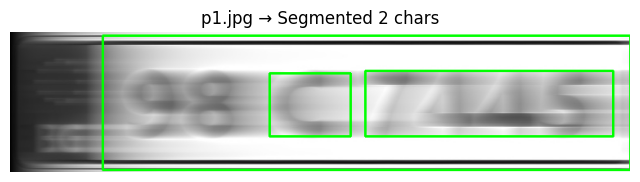

p1.jpg : Recognized -> C1
----------------------------------------



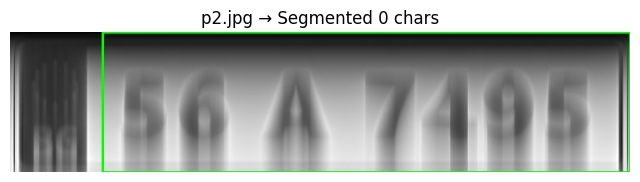

p2.jpg : Recognized -> 
----------------------------------------



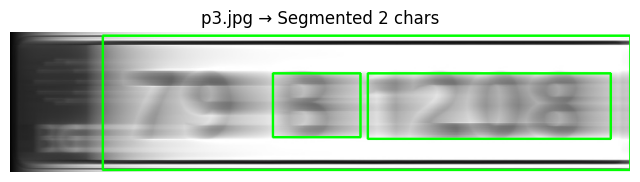

p3.jpg : Recognized -> 91
----------------------------------------



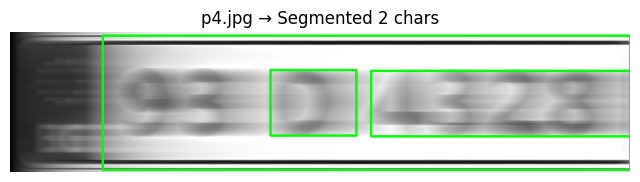

p4.jpg : Recognized -> B0
----------------------------------------



In [39]:
# Part 1 : 
import cv2
import glob
import os
import matplotlib.pyplot as plt

realistic_folder = "realistic"
letters_folder   = "letters"
numbers_folder   = "numbers"

templates = {}
for path in glob.glob(os.path.join(letters_folder, "*.jpg")) + glob.glob(os.path.join(numbers_folder, "*.jpg")):
    label = os.path.splitext(os.path.basename(path))[0]
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    _, tmpl = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    templates[label] = tmpl

# Ideal Section Functions
def segment_characters(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    x0 = int(w * 0.15)
    roi = gray[:, x0:]
    _, thresh = cv2.threshold(roi, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    clean = cv2.morphologyEx(thresh,
                             cv2.MORPH_CLOSE,
                             cv2.getStructuringElement(cv2.MORPH_RECT, (5,5)))
    cnts, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes = [(x,y,cw,ch) for c in cnts
             for x,y,cw,ch in [cv2.boundingRect(c)]
             if ch > h*0.4 and cw > w*0.03]
    boxes = sorted(boxes, key=lambda b: b[0])
    chars = [clean[y:y+ch, x:x+cw] for x,y,cw,ch in boxes]
    boxes_in_img = [(x+x0, y, cw, ch) for x,y,cw,ch in boxes]
    return chars, boxes_in_img

def recognize_plate(chars):
    plate = ""
    for ch_img in chars:
        best_char, best_val = None, -1
        for label, tmpl in templates.items():
            tmpl_rs = cv2.resize(tmpl, (ch_img.shape[1], ch_img.shape[0]))
            res = cv2.matchTemplate(ch_img, tmpl_rs, cv2.TM_CCOEFF_NORMED)
            val = res.max()
            if val > best_val:
                best_val, best_char = val, label
        plate += best_char or "?"
    return plate[1:]  

# Running the test without Deblurring
print("*** Recognition without Deblurring ***\n")
for path in sorted(glob.glob(os.path.join(realistic_folder, "p*.jpg"))):
    img = cv2.imread(path)
    chars, boxes = segment_characters(img)
    pred = recognize_plate(chars)
    
    vis = img.copy()
    for (x,y,cw,ch) in boxes:
        cv2.rectangle(vis, (x,y), (x+cw, y+ch), (0,255,0), 2)
    plt.figure(figsize=(8,2))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(f"{os.path.basename(path)} → Segmented {len(chars)-1} chars")
    plt.axis('off')
    plt.show()
    
    print(f"{os.path.basename(path)} : Recognized -> {pred}\n{'-'*40}\n")

In [45]:
# Part 2 : 
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt   

# PSF and Inverse Filter
def build_psf(p, thresh=1e-3):
    n_max = int(np.ceil(np.log(thresh) / np.log(p)))   # Length automatically
    n     = np.arange(n_max + 1)
    h     = (1-p) * p**n
    return h / h.sum()

def inverse_line(sig, H, eps=1e-3):
    F = np.fft.fft(sig)
    G = F * np.conj(H) / (np.abs(H)**2 + eps)
    return np.real(np.fft.ifft(G))

def deblur(img, p, axis=1, eps=1e-3):
    h = build_psf(p)            
    L = img.shape[axis]         

    if len(h) > L:              # If the core is longer than the image → crop
        h = h[:L]

    if len(h) < L:
        h_pad = np.pad(h, (0, L-len(h)))
    else:
        h_pad = h               

    H = np.fft.fft(h_pad)

    if axis == 1:               
        out = np.stack([inverse_line(img[r], H, eps) for r in range(img.shape[0])])
    else:                       
        out = np.stack([inverse_line(img[:,c], H, eps) for c in range(img.shape[1])], axis=1)

    return np.clip(out, 0, 1)

def sharpness(im):
    gx, gy = np.gradient(im)
    return (gx**2 + gy**2).var()

def best_axis_p(img, p_grid, eps=1e-3):
    best = (-np.inf, None, None, None)   
    for axis in (0,1):
        for p in p_grid:
            deb = deblur(img, p, axis, eps)
            s   = sharpness(deb)
            if s > best[0]:
                best = (s, axis, p, deb)
    return best[1:]   

def deblur_batch(paths, p_min=0.5, p_max=0.99, num_p=25, eps=1e-3, overwrite=True):
    p_grid = np.linspace(p_min, p_max, num_p)
    results = {}
    for path in paths:
        img = np.array(Image.open(path).convert('L'))/255.
        axis, p_hat, deb = best_axis_p(img, p_grid, eps)
        out_path = Path(path).with_stem(Path(path).stem + '_deblur')
        if overwrite or not out_path.exists():
            Image.fromarray((deb*255).astype('uint8')).save(out_path)
        results[path] = dict(axis=('horizontal','vertical')[axis==0], p=p_hat, out=out_path)
        print(f'{Path(path).name:>10}: axis={results[path]["axis"]:<10}  p={p_hat:0.4f}')
    return results

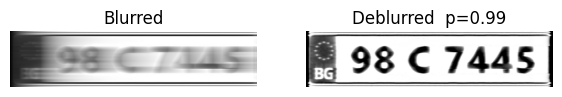

In [46]:
# For p1.jpg
img_path = Path(r'C:/Users/Mojtaba/Desktop/Phase2_S&S/Realistic Case/realistic/p1.jpg')

p_value = 0.99      
axis    = 1           

img = np.array(Image.open(img_path).convert('L')) / 255.
deb = deblur(img, p_value, axis, eps=1e-3)   

plt.figure(figsize=(7,3))
plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title('Blurred');  plt.axis('off')
plt.subplot(1,2,2); plt.imshow(deb, cmap='gray'); plt.title(f'Deblurred  p={p_value}'); plt.axis('off')
plt.show()

out_path = img_path.with_stem(img_path.stem + f'_manual_{p_value:.2f}')
Image.fromarray((deb*255).astype('uint8')).save(out_path)

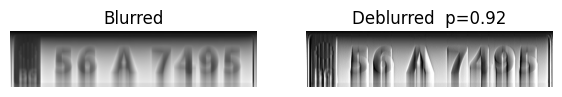

In [47]:
# For p2.jpg
img_path = Path(r'C:/Users/Mojtaba/Desktop/Phase2_S&S/Realistic Case/realistic/p2.jpg')

p_value = 0.92     
axis    = 1          

img = np.array(Image.open(img_path).convert('L')) / 255.
deb = deblur(img, p_value, axis, eps=1e-3)   

plt.figure(figsize=(7,3))
plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title('Blurred');  plt.axis('off')
plt.subplot(1,2,2); plt.imshow(deb, cmap='gray'); plt.title(f'Deblurred  p={p_value}'); plt.axis('off')
plt.show()

out_path = img_path.with_stem(img_path.stem + f'_manual_{p_value:.2f}')
Image.fromarray((deb*255).astype('uint8')).save(out_path)

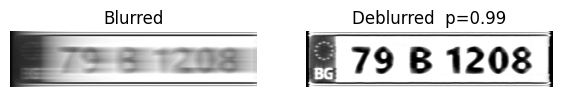

In [48]:
# For p3.jpg
img_path = Path(r'C:/Users/Mojtaba/Desktop/Phase2_S&S/Realistic Case/realistic/p3.jpg')

p_value = 0.99     
axis    = 1           

img = np.array(Image.open(img_path).convert('L')) / 255.
deb = deblur(img, p_value, axis, eps=1e-3)   

plt.figure(figsize=(7,3))
plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title('Blurred');  plt.axis('off')
plt.subplot(1,2,2); plt.imshow(deb, cmap='gray'); plt.title(f'Deblurred  p={p_value}'); plt.axis('off')
plt.show()

out_path = img_path.with_stem(img_path.stem + f'_manual_{p_value:.2f}')
Image.fromarray((deb*255).astype('uint8')).save(out_path)

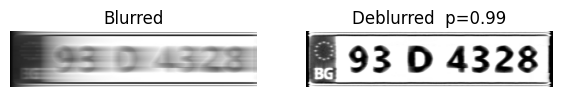

In [49]:
# For p4.jpg
img_path = Path(r'C:/Users/Mojtaba/Desktop/Phase2_S&S/Realistic Case/realistic/p4.jpg')

p_value = 0.99     
axis    = 1           

img = np.array(Image.open(img_path).convert('L')) / 255.
deb = deblur(img, p_value, axis, eps=1e-3)   

plt.figure(figsize=(7,3))
plt.subplot(1,2,1); plt.imshow(img, cmap='gray'); plt.title('Blurred');  plt.axis('off')
plt.subplot(1,2,2); plt.imshow(deb, cmap='gray'); plt.title(f'Deblurred  p={p_value}'); plt.axis('off')
plt.show()

out_path = img_path.with_stem(img_path.stem + f'_manual_{p_value:.2f}')
Image.fromarray((deb*255).astype('uint8')).save(out_path)

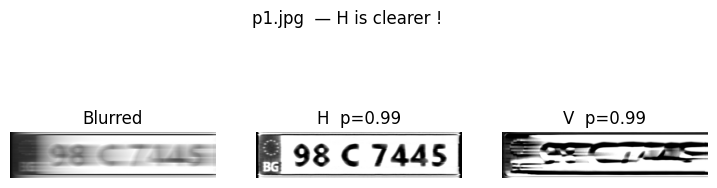

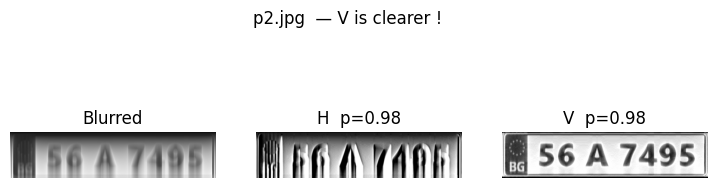

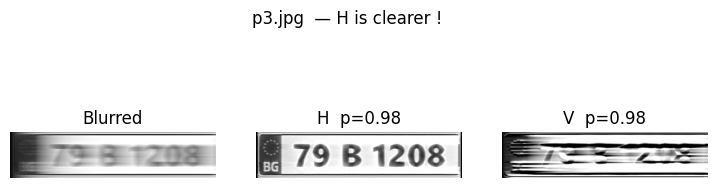

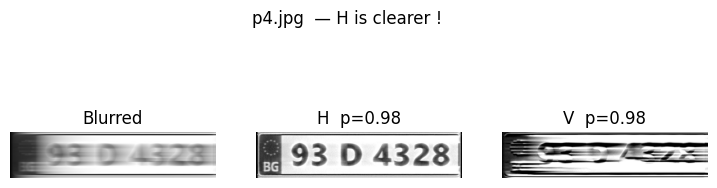

In [60]:
# Part 3 : 
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# PSF + inverse filter
def build_psf(p, thresh=1e-3):
    n_max = int(np.ceil(np.log(thresh) / np.log(p)))      
    n     = np.arange(n_max + 1)
    h     = (1 - p) * p**n
    return h / h.sum()

def inverse_line(sig, H, eps=1e-3):
    F = np.fft.fft(sig)
    G = F * np.conj(H) / (np.abs(H)**2 + eps)             
    return np.real(np.fft.ifft(G))

def deblur(img, p, axis=1, eps=1e-3):
    h = build_psf(p)
    L = img.shape[axis]
    h = h[:L] if len(h) > L else h                        # crop if kernel > line
    H = np.fft.fft(np.pad(h, (0, L-len(h))))              # zero-pad to length L
    if axis == 1:   # horizontal
        out = np.stack([inverse_line(img[r], H, eps) for r in range(img.shape[0])])
    else:           # vertical
        out = np.stack([inverse_line(img[:,c], H, eps) for c in range(img.shape[1])], axis=1)
    return np.clip(out, 0, 1)

def sharpness(im):
    gx, gy = np.gradient(im)
    return (gx**2 + gy**2).var()

def deblur_single(path, p, eps=1e-3, overwrite=True, show=True):
    img     = np.array(Image.open(path).convert('L')) / 255.
    deb_h   = deblur(img, p, axis=1, eps=eps)
    deb_v   = deblur(img, p, axis=0, eps=eps)
    s_h, s_v = sharpness(deb_h), sharpness(deb_v)

    out_h = path.with_stem(path.stem + f'_deblur_h_{p:.2f}')
    out_v = path.with_stem(path.stem + f'_deblur_v_{p:.2f}')
    if overwrite or not out_h.exists():
        Image.fromarray((deb_h*255).astype('uint8')).save(out_h)
    if overwrite or not out_v.exists():
        Image.fromarray((deb_v*255).astype('uint8')).save(out_v)

    # choose clearer image
    best_path = out_h if s_h >= s_v else out_v

    if show:
        plt.figure(figsize=(9,3))
        plt.subplot(1,3,1); plt.imshow(img,   cmap='gray'); plt.title('Blurred');      plt.axis('off')
        plt.subplot(1,3,2); plt.imshow(deb_h, cmap='gray'); plt.title(f'H  p={p:.2f}'); plt.axis('off')
        plt.subplot(1,3,3); plt.imshow(deb_v, cmap='gray'); plt.title(f'V  p={p:.2f}'); plt.axis('off')
        plt.suptitle(f"{path.name}  — {'V' if best_path==out_h else 'H'} is clearer !")
        plt.show()

    return dict(h=out_h, v=out_v, best=best_path, p=p, sharp_h=s_h, sharp_v=s_v)

def deblur_folder(folder, p_map, eps=1e-3):
    results = {}
    for img_path in sorted(folder.glob('*.jpg')):
        p = p_map.get(img_path.name, p_map.get('default', 0.98))
        results[img_path] = deblur_single(img_path, p, eps, show=True)
    return results

folder = Path(r'C:/Users/Mojtaba/Desktop/Phase2_S&S/Realistic Case/realistic')
p_opt  = {'default':0.98, 'p1.jpg':0.99}  
results = deblur_folder(folder, p_opt)

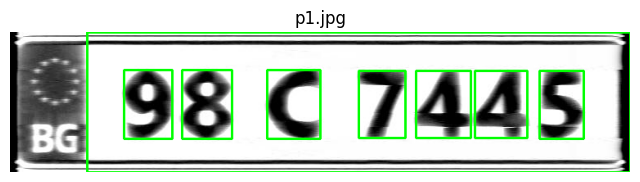

Recognised plate :  98C7445
   Char 1: 9   (corr=0.68)
   Char 2: 8   (corr=0.69)
   Char 3: C   (corr=0.71)
   Char 4: 7   (corr=0.68)
   Char 5: 4   (corr=0.81)
   Char 6: 4   (corr=0.72)
   Char 7: 5   (corr=0.66)
----------------------------------------



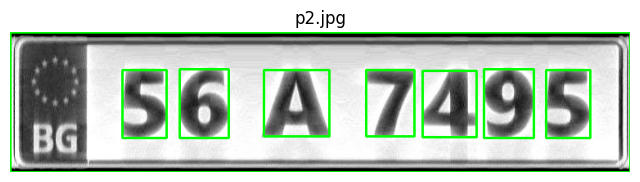

Recognised plate :  56A7495
   Char 1: 5   (corr=0.64)
   Char 2: 6   (corr=0.69)
   Char 3: A   (corr=0.78)
   Char 4: 7   (corr=0.73)
   Char 5: 4   (corr=0.80)
   Char 6: 9   (corr=0.70)
   Char 7: 5   (corr=0.64)
----------------------------------------



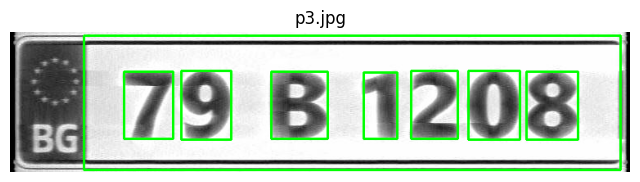

Recognised plate :  79B1208
   Char 1: 7   (corr=0.76)
   Char 2: 9   (corr=0.68)
   Char 3: B   (corr=0.60)
   Char 4: 1   (corr=0.67)
   Char 5: 2   (corr=0.64)
   Char 6: 0   (corr=0.68)
   Char 7: 8   (corr=0.69)
----------------------------------------



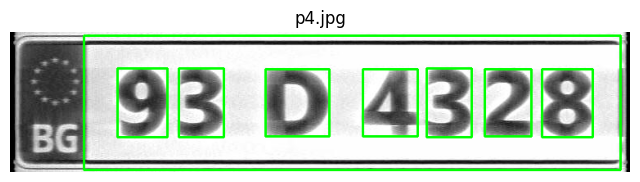

Recognised plate :  93D4328
   Char 1: 9   (corr=0.67)
   Char 2: 3   (corr=0.68)
   Char 3: D   (corr=0.65)
   Char 4: 4   (corr=0.81)
   Char 5: 3   (corr=0.68)
   Char 6: 2   (corr=0.63)
   Char 7: 8   (corr=0.65)
----------------------------------------



In [ ]:
# Part 4 : 
import cv2, glob, os, matplotlib.pyplot as plt

letters_folder  = "letters"   
numbers_folder  = "numbers"   
templates = {}

for tp in (glob.glob(os.path.join(letters_folder, "*.jpg"))
           + glob.glob(os.path.join(numbers_folder, "*.jpg"))):
    label = os.path.splitext(os.path.basename(tp))[0]
    img   = cv2.imread(tp, cv2.IMREAD_GRAYSCALE)
    _, bw = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    templates[label] = bw                          

def segment_characters(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    # cutting
    def find_strip_end(g):
        col = g.mean(axis=0)
        thr = 0.95*col.max()
        for i in range(int(0.25*w)):      
            if col[i] > thr:
                return i
        return int(0.12*w)
    x0  = find_strip_end(gray)
    roi = gray[:, x0:]

    # Binary and Cleanup
    _, binv = cv2.threshold(roi, 0, 255,
                             cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    kernel  = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
    clean   = cv2.morphologyEx(binv, cv2.MORPH_CLOSE, kernel)

    # Contour
    cnts, _ = cv2.findContours(clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes   = []
    for c in cnts:
        x, y, cw, ch = cv2.boundingRect(c)
        if ch > 0.35*h and cw > 0.02*w:  
            boxes.append((x, y, cw, ch))
    boxes = sorted(boxes, key=lambda b: b[0])
    chars = [clean[y:y+ch, x:x+cw] for x, y, cw, ch in boxes]
    return chars, boxes, x0

# correlation-based template matching
def recognise_plate(chars, templates):
    plate_txt, details = "", []
    for ch in chars:
        best_label, best_corr = None, -1
        for lbl, tmpl in templates.items():
            tmpl_rs = cv2.resize(tmpl, (ch.shape[1], ch.shape[0]))
            corr    = cv2.matchTemplate(ch, tmpl_rs,
                                        cv2.TM_CCOEFF_NORMED).max()
            if corr > best_corr:
                best_corr, best_label = corr, lbl
        plate_txt += best_label if best_label else "?"
        details.append((best_label, best_corr))
    return plate_txt, details

real_folder = "realistic_Part4"
for path in sorted(glob.glob(os.path.join(real_folder, "p*.jpg"))):
    img   = cv2.imread(path)             
    chars, boxes, x0 = segment_characters(img)

    vis = img.copy()
    for x,y,w_,h_ in boxes:
        cv2.rectangle(vis, (x0+x, y), (x0+x+w_, y+h_), (0,255,0), 2)

    plt.figure(figsize=(8,4))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(os.path.basename(path))
    plt.axis('off')
    plt.show()

    plate, corr_info = recognise_plate(chars, templates)
    plate  = plate[1:]          
    corr_info = corr_info[1:]

    print(f"Recognised plate :  {plate}")
    for idx, (c, v) in enumerate(corr_info, 1):
        print(f"   Char {idx}: {c}   (corr={v:.2f})")
    print("-"*40 + "\n")

----------------------------------------------------------------------------------------------------------------------

===== p1.jpg (GT=98C7445) =====
  down 1/1  → "98C7445" ✓


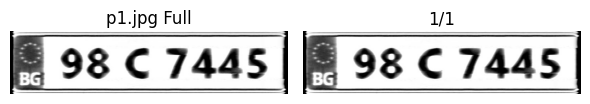

  down 1/2  → "98C705" ✗


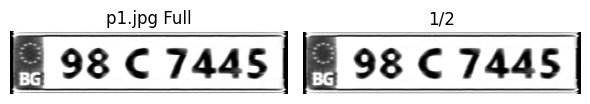

  down 1/3  → "0C705" ✗


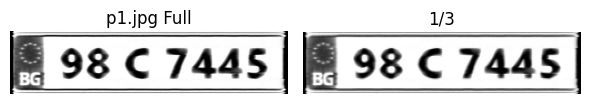

  down 1/4  → "0C705" ✗


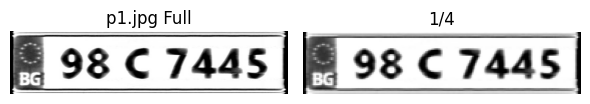

  down 1/5  → "BC7C" ✗


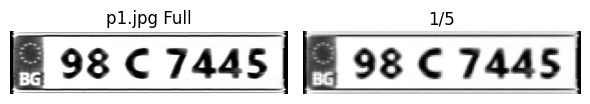

  down 1/5  → "C71" ✗


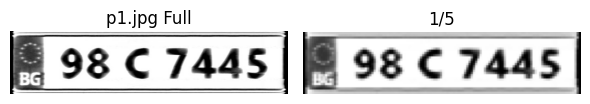

----------------------------------------------------------------------------------------------------------------------

===== p2.jpg (GT=56A7495) =====
  down 1/1  → "56A7495" ✓


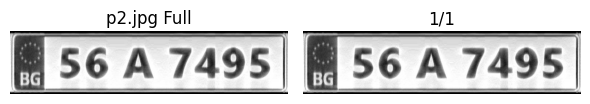

  down 1/2  → "56A7495" ✓


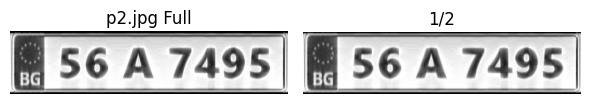

  down 1/3  → "" ✗


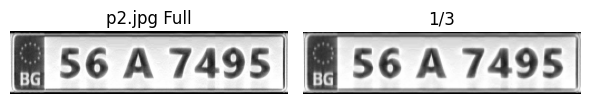

  down 1/4  → "" ✗


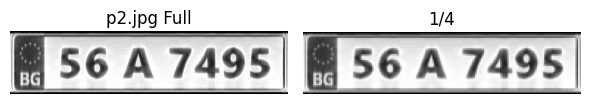

  down 1/5  → "BA71" ✗


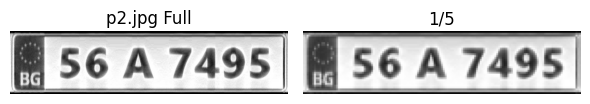

  down 1/5  → "BA7" ✗


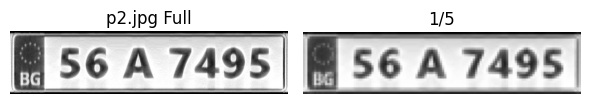

----------------------------------------------------------------------------------------------------------------------

===== p3.jpg (GT=79B1208) =====
  down 1/1  → "79B1208" ✓


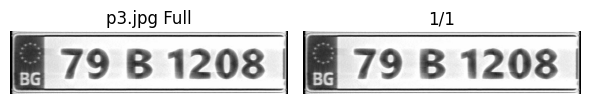

  down 1/2  → "" ✗


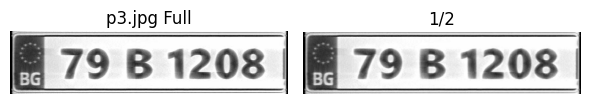

  down 1/3  → "" ✗


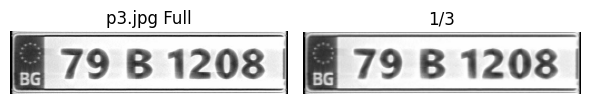

  down 1/4  → "" ✗


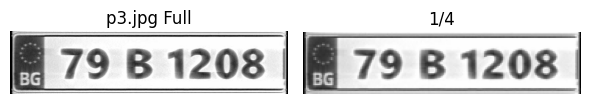

  down 1/5  → "" ✗


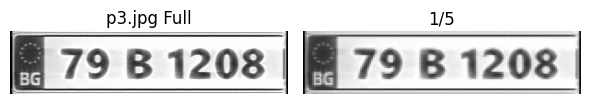

  down 1/5  → "" ✗


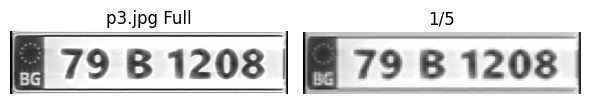

----------------------------------------------------------------------------------------------------------------------

===== p4.jpg (GT=93D4328) =====
  down 1/1  → "93D4328" ✓


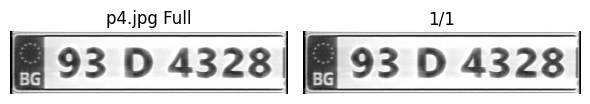

  down 1/2  → "" ✗


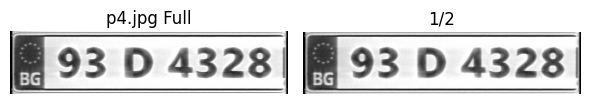

  down 1/3  → "" ✗


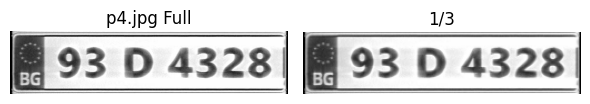

  down 1/4  → "" ✗


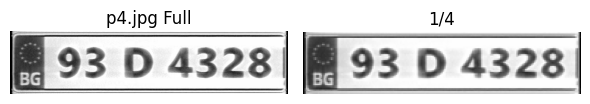

  down 1/5  → "" ✗


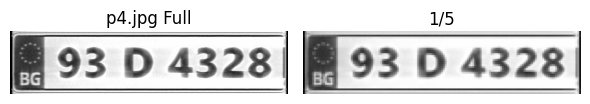

  down 1/5  → "" ✗


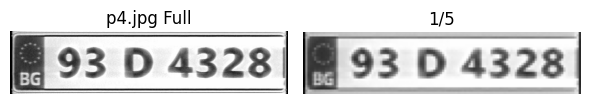

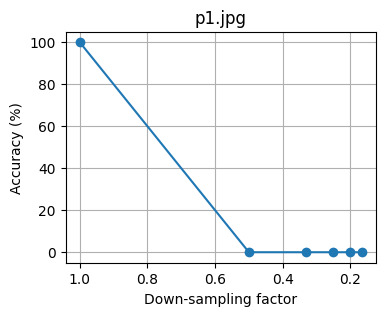

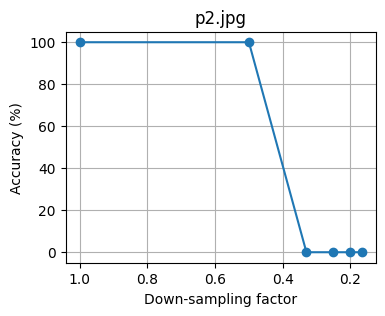

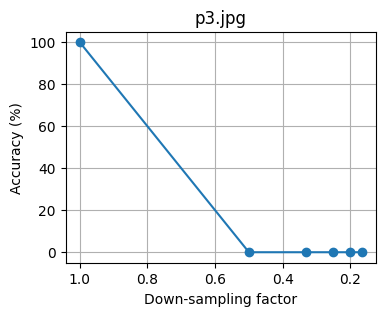

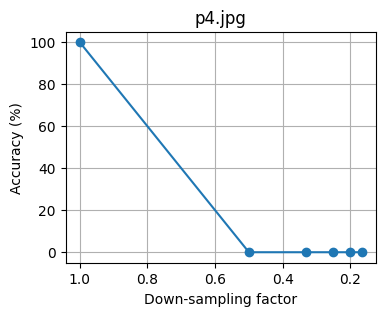

correct
image  rate          
p1.jpg 0.167      0.0
       0.200      0.0
       0.250      0.0
       0.330      0.0
       0.500      0.0
       1.000      1.0
p2.jpg 0.167      0.0
       0.200      0.0
       0.250      0.0
       0.330      0.0
       0.500      1.0
       1.000      1.0
p3.jpg 0.167      0.0
       0.200      0.0
       0.250      0.0
       0.330      0.0
       0.500      0.0
       1.000      1.0
p4.jpg 0.167      0.0
       0.200      0.0
       0.250      0.0
       0.330      0.0
       0.500      0.0
       1.000      1.0

In [70]:
# Part 5 : 
import cv2, matplotlib.pyplot as plt, pandas as pd
from pathlib import Path

plate_gt = {'p1.jpg':'98C7445','p2.jpg':'56A7495','p3.jpg':'79B1208','p4.jpg':'93D4328'}
rates    = [1,0.50,0.33,0.25,0.20,0.167]
src_dir  = Path('realistic_Part4')

def downsample(im,f): return im if f==1 else cv2.resize(im,(int(im.shape[1]*f),int(im.shape[0]*f)),interpolation=cv2.INTER_AREA)
def recognise_plate_img(img): 
    chars,_,_ = segment_characters(img)
    return "" if not chars else recognise_plate(chars,templates)[0][1:]  

records=[]
for f in sorted(src_dir.glob('p*.jpg')):
    im0 = cv2.imread(str(f)); gt=plate_gt[f.name]
    print("----------------------------------------------------------------------------------------------------------------------")
    print(f'\n===== {f.name} (GT={gt}) =====')
    for r in rates:
        im_ds = downsample(im0,r)
        recog = recognise_plate_img(im_ds)
        ok    = recog==gt
        records.append(dict(image=f.name,rate=r,recog=recog,correct=ok))
        print(f'  down 1/{int(1/r):<2} → "{recog}" {"✓" if ok else "✗"}')

        # Plots for each license plate and each rate
        plt.figure(figsize=(6,2))
        plt.subplot(1,2,1); plt.imshow(cv2.cvtColor(im0,cv2.COLOR_BGR2RGB)); plt.title(f'{f.name} Full'); plt.axis('off')
        plt.subplot(1,2,2); plt.imshow(cv2.cvtColor(im_ds,cv2.COLOR_BGR2RGB)); plt.title(f'1/{int(1/r)}'); plt.axis('off')
        plt.tight_layout(); plt.show()

df = pd.DataFrame(records)

# Accuracy vs. down-sampling factor chart for each license plate
for img_name, grp in df.groupby('image'):
    plt.figure(figsize=(4,3))
    plt.plot(grp['rate'], grp['correct']*100, marker='o')
    plt.gca().invert_xaxis()         # Left = higher resolution
    plt.title(img_name)
    plt.xlabel('Down-sampling factor')
    plt.ylabel('Accuracy (%)')
    plt.ylim(-5, 105)
    plt.grid(True)
    plt.show()

pivot = df.pivot_table(index=['image','rate'], values='correct')
display(pivot)